# Autoencoder — Détection de Fraudes Financières
**Modèle non supervisé de détection d'anomalies par reconstruction**

---
### Principe
L'Autoencoder apprend à **reconstruire les transactions normales**.
Une transaction frauduleuse sera mal reconstruite → erreur élevée → anomalie détectée.

```
Transaction → Encoder → Latent z → Decoder → Reconstruction
                                                    ↓
                              Erreur de reconstruction = score d'anomalie
```

##  1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print('✅ Imports réussis')

TensorFlow : 2.20.0
✅ Imports réussis


##  2. Google Drive + Chargement des données

In [4]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH   = '/content/drive/MyDrive/fraud_detection/data/'
MODELS_PATH = '/content/drive/MyDrive/fraud_detection/models/'
os.makedirs(MODELS_PATH, exist_ok=True)

X_all    = np.load(BASE_PATH + 'X_data.npy')
y        = np.load(BASE_PATH + 'y_detection.npy')
X_normal = np.load(BASE_PATH + 'X_normal.npy')

print(f'X_all    : {X_all.shape}    → dataset complet normalisé')
print(f'y        : {y.shape}  → labels (0=normal, 1=fraude)')
print(f'X_normal : {X_normal.shape}  → transactions normales uniquement')
print(f'\n📊 Taux de fraude réel : {y.mean()*100:.2f}%')
print(f'   Fraudes  : {int(y.sum()):,}')
print(f'   Normales : {int((y==0).sum()):,}')

Mounted at /content/drive
X_all    : (1000000, 43)    → dataset complet normalisé
y        : (1000000, 1)  → labels (0=normal, 1=fraude)
X_normal : (982857, 43)  → transactions normales uniquement

📊 Taux de fraude réel : 1.71%
   Fraudes  : 17,143
   Normales : 982,857


##  3. Architecture de l'Autoencoder

```
Input (43) → Dense(64) → BN → Dropout → Dense(32) → BN → Latent(8)
                                                              ↓
Output (43) ← Dense(64) ← BN ← Dense(32) ← BN ←────────────┘
```

In [5]:
input_dim  = X_all.shape[1]
latent_dim = 8

# ── Encoder ──
encoder_input = keras.Input(shape=(input_dim,), name='encoder_input')
x = layers.Dense(64, activation='relu')(encoder_input)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.BatchNormalization()(x)
latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
encoder = Model(encoder_input, latent, name='Encoder')

# ── Decoder ──
decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')
x = layers.Dense(32, activation='relu')(decoder_input)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x)
decoder = Model(decoder_input, decoder_output, name='Decoder')

# ── Autoencoder complet ──
ae_input  = keras.Input(shape=(input_dim,))
encoded   = encoder(ae_input)
decoded   = decoder(encoded)
autoencoder = Model(ae_input, decoded, name='Autoencoder')

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)

print(f'Input dim  : {input_dim}')
print(f'Latent dim : {latent_dim}')
print(f'\n── Encoder ──')
encoder.summary()
print(f'\n── Decoder ──')
decoder.summary()

Input dim  : 43
Latent dim : 8

── Encoder ──


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 43)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,544 (21.66 KB)

 Trainable params: 5,352 (20.91 KB)

...

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 43)             │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,579 (21.79 KB)

 Trainable params: 5,387 (21.04 KB)

 Non-trainable params: 192 (768.00 B)

##  4. Entraînement

> **Rappel** : On entraîne uniquement sur `X_normal` — les transactions légitimes.
> L'AE apprend à reconstruire le comportement normal. Les fraudes seront mal reconstruites.

In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print('⏳ Entraînement en cours...')
history = autoencoder.fit(
    X_normal, X_normal,
    epochs          = 100,
    batch_size      = 256,
    validation_split= 0.15,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)
print('✅ Entraînement terminé')
print(f'   Époques effectuées : {len(history.history["loss"])}')
print(f'   Meilleure val_loss : {min(history.history["val_loss"]):.6f}')

⏳ Entraînement en cours...
Epoch 1/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 0.4404 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 2/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.3068 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 3/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.2719 - val_loss: 0.2264 - learning_rate: 0.0010
Epoch 4/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 0.2524 - val_loss: 0.2077 - learning_rate: 0.0010
Epoch 5/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.2314 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 6/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.2157 - val_loss: 0.1755 - learning_rate: 0.0010
Epoch 7/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.2054 - val_loss: 0.1668 - learning_rate: 0.0010
Epoch 8/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.1976 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 9/100
3264/3264 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - los

## 📉 5. Courbe d'apprentissage

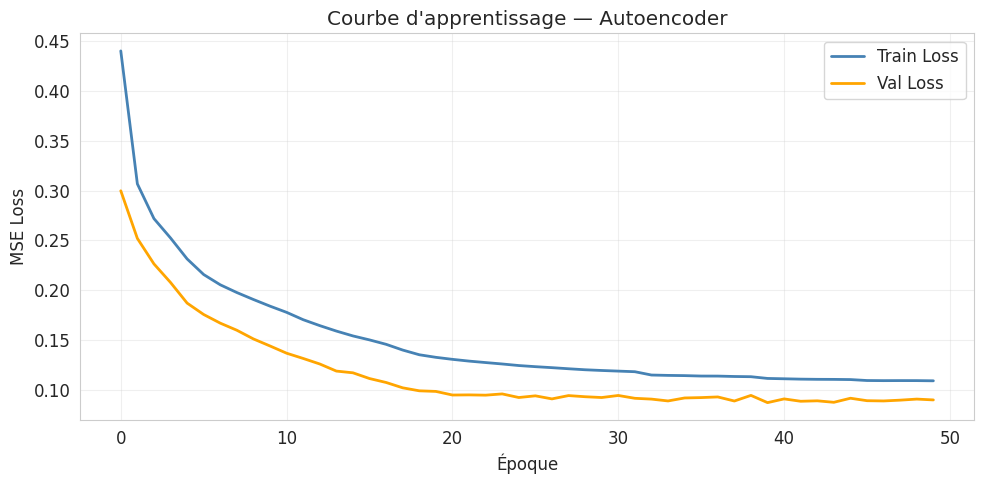

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue', lw=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='orange',    lw=2)
ax.set_xlabel('Époque')
ax.set_ylabel('MSE Loss')
ax.set_title("Courbe d'apprentissage — Autoencoder")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_PATH + 'ae_learning_curve.png', dpi=150)
plt.show()

## 🔍 6. Calcul des scores d'anomalie

Le score d'anomalie = erreur de reconstruction (MSE) par transaction.
Plus l'erreur est élevée, plus la transaction est suspecte.

In [10]:
print('Reconstruction du dataset complet...')
X_reconstructed = autoencoder.predict(X_all, batch_size=512, verbose=1)

# Erreur de reconstruction par transaction (MSE)
ae_scores = np.mean(np.square(X_all - X_reconstructed), axis=1)

# Normalisation entre 0 et 1
ae_scores_norm = (ae_scores - ae_scores.min()) / \
                 (ae_scores.max() - ae_scores.min())

print(f'\nScore min    : {ae_scores_norm.min():.4f}')
print(f'Score max    : {ae_scores_norm.max():.4f}')
print(f'Score moyen  : {ae_scores_norm.mean():.4f}')
print(f'\nErreur moy. normales : {ae_scores_norm[y.flatten()==0].mean():.4f}')
print(f'Erreur moy. fraudes  : {ae_scores_norm[y.flatten()==1].mean():.4f}')

Reconstruction du dataset complet...
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

Score min    : 0.0000
Score max    : 1.0000
Score moyen  : 0.0369

Erreur moy. normales : 0.0370
Erreur moy. fraudes  : 0.0365


## 📊 7. Évaluation initiale

In [11]:
roc_auc = roc_auc_score(y, ae_scores_norm)
pr_auc  = average_precision_score(y, ae_scores_norm)

# Seuil initial basé sur le taux de fraude réel
taux_fraude    = y.mean()
threshold_init = np.percentile(ae_scores_norm, (1 - taux_fraude) * 100)
y_pred_init    = (ae_scores_norm >= threshold_init).astype(int)
f1_init        = f1_score(y, y_pred_init)

print('=' * 50)
print('    RÉSULTATS — SEUIL PAR DÉFAUT')
print('=' * 50)
print(f'  ROC-AUC      : {roc_auc:.4f}')
print(f'  PR-AUC       : {pr_auc:.4f}')
print(f'  F1-Score     : {f1_init:.4f}')
print(f'  Seuil (init) : {threshold_init:.4f}')
print('=' * 50)
print(classification_report(y, y_pred_init,
      target_names=['Normal', 'Fraude']))

    RÉSULTATS — SEUIL PAR DÉFAUT
  ROC-AUC      : 0.4921
  PR-AUC       : 0.0169
  F1-Score     : 0.0172
  Seuil (init) : 0.2837
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98    982857
      Fraude       0.02      0.02      0.02     17143

    accuracy                           0.97   1000000
   macro avg       0.50      0.50      0.50   1000000
weighted avg       0.97      0.97      0.97   1000000



## 🔲 8. Matrice de confusion — seuil initial

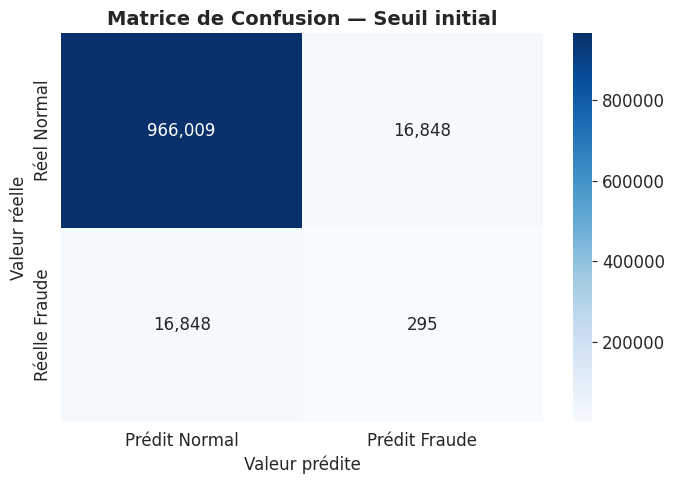

TN : 966,009 → normaux correctement classifiés
FP : 16,848 → normaux signalés comme fraude (fausses alarmes)
FN : 16,848 → fraudes manquées ⚠️
TP : 295 → fraudes correctement détectées ✅


In [12]:
cm = confusion_matrix(y, y_pred_init)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Réel Normal', 'Réelle Fraude'], ax=ax)
ax.set_title('Matrice de Confusion — Seuil initial',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valeur réelle')
ax.set_xlabel('Valeur prédite')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'ae_confusion_matrix_init.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN : {tn:,} → normaux correctement classifiés')
print(f'FP : {fp:,} → normaux signalés comme fraude (fausses alarmes)')
print(f'FN : {fn:,} → fraudes manquées ⚠️')
print(f'TP : {tp:,} → fraudes correctement détectées ✅')

## 📈 9. Courbes ROC et Precision-Recall

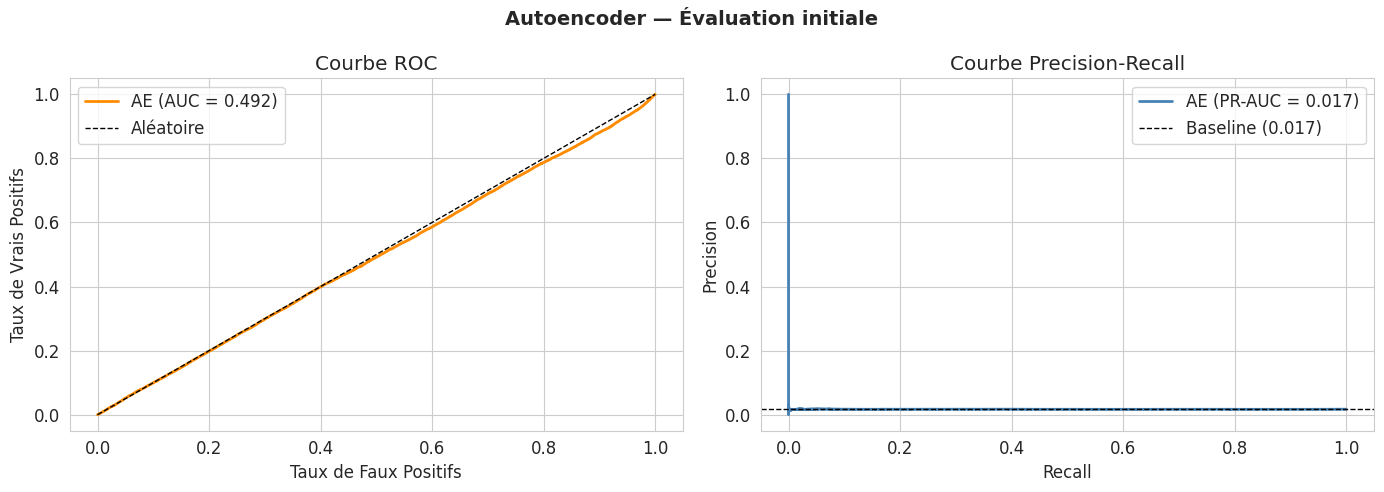

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y, ae_scores_norm)
axes[0].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'AE (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbe ROC')
axes[0].legend()
axes[0].grid(True)

precision_vals, recall_vals, _ = precision_recall_curve(y, ae_scores_norm)
axes[1].plot(recall_vals, precision_vals, color='steelblue', lw=2,
             label=f'AE (PR-AUC = {pr_auc:.3f})')
axes[1].axhline(y=y.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline ({y.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Autoencoder — Évaluation initiale',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'ae_roc_pr_curves.png', dpi=150)
plt.show()

## 🎯 10. Optimisation du seuil

On cherche le seuil qui maximise le F1-score sur les fraudes,
directement sur les scores finaux.

Seuil optimal   : 0.0215
Meilleur F1     : 0.0345
Fraudes prédites: 354,800
Fraudes réelles : 17,143


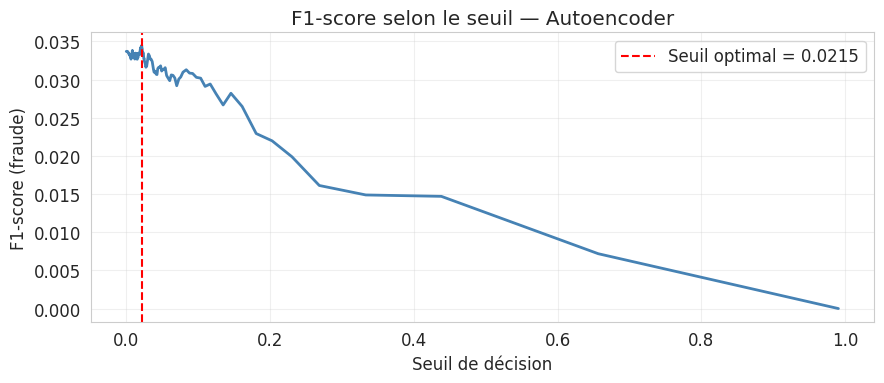

In [14]:
from sklearn.utils import resample

# Sous-échantillon stratifié pour accélérer la recherche
idx_sample = resample(
    np.arange(len(y)),
    n_samples    = 50_000,
    stratify     = y,
    random_state = 42
)
scores_sample = ae_scores_norm[idx_sample]
y_sample      = y[idx_sample]

_, _, thresholds_pr = precision_recall_curve(y_sample, scores_sample)

# Tester 200 seuils uniformément espacés
thresholds_test = thresholds_pr[
    ::max(1, len(thresholds_pr) // 200)
]

f1s = [f1_score(y_sample, (scores_sample >= t).astype(int),
                zero_division=0) for t in thresholds_test]

best_threshold = float(thresholds_test[np.argmax(f1s)])
best_f1        = max(f1s)

print(f'Seuil optimal   : {best_threshold:.4f}')
print(f'Meilleur F1     : {best_f1:.4f}')
print(f'Fraudes prédites: {(ae_scores_norm >= best_threshold).sum():,}')
print(f'Fraudes réelles : {int(y.sum()):,}')

# Courbe F1 selon le seuil
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_test, f1s, color='steelblue', lw=2)
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'Seuil optimal = {best_threshold:.4f}')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('F1-score (fraude)')
ax.set_title('F1-score selon le seuil — Autoencoder')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🏆 11. Évaluation finale avec seuil optimisé

── Rapport final avec seuil optimisé ──
              precision    recall  f1-score   support

      Normal       0.98      0.65      0.78    982857
      Fraude       0.02      0.35      0.03     17143

    accuracy                           0.64   1000000
   macro avg       0.50      0.50      0.41   1000000
weighted avg       0.97      0.64      0.77   1000000



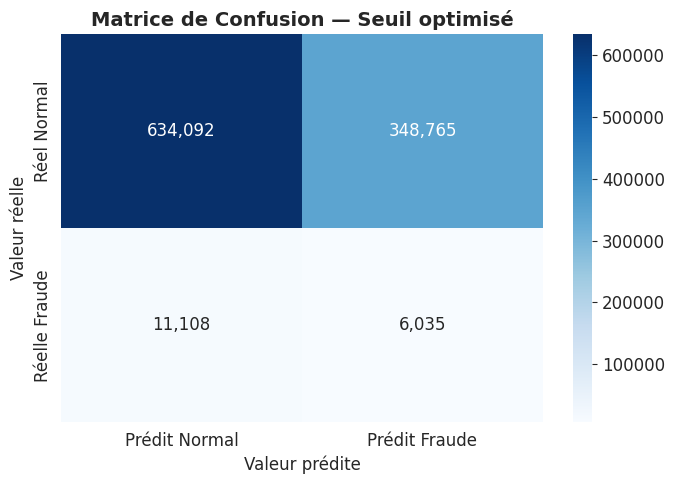

TN : 634,092 | FP : 348,765 | FN : 11,108 | TP : 6,035


In [15]:
y_pred_final = (ae_scores_norm >= best_threshold).astype(int)

roc_final = roc_auc_score(y, ae_scores_norm)
pr_final  = average_precision_score(y, ae_scores_norm)
f1_final  = f1_score(y, y_pred_final)

print('── Rapport final avec seuil optimisé ──')
print(classification_report(y, y_pred_final,
      target_names=['Normal', 'Fraude']))

# Matrice de confusion finale
cm_final = confusion_matrix(y, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Réel Normal', 'Réelle Fraude'], ax=ax)
ax.set_title('Matrice de Confusion — Seuil optimisé',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valeur réelle')
ax.set_xlabel('Valeur prédite')
plt.tight_layout()
plt.savefig(MODELS_PATH + 'ae_confusion_matrix_optimal.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_final.ravel()
print(f'TN : {tn:,} | FP : {fp:,} | FN : {fn:,} | TP : {tp:,}')

## 📉 12. Distribution des scores d'anomalie

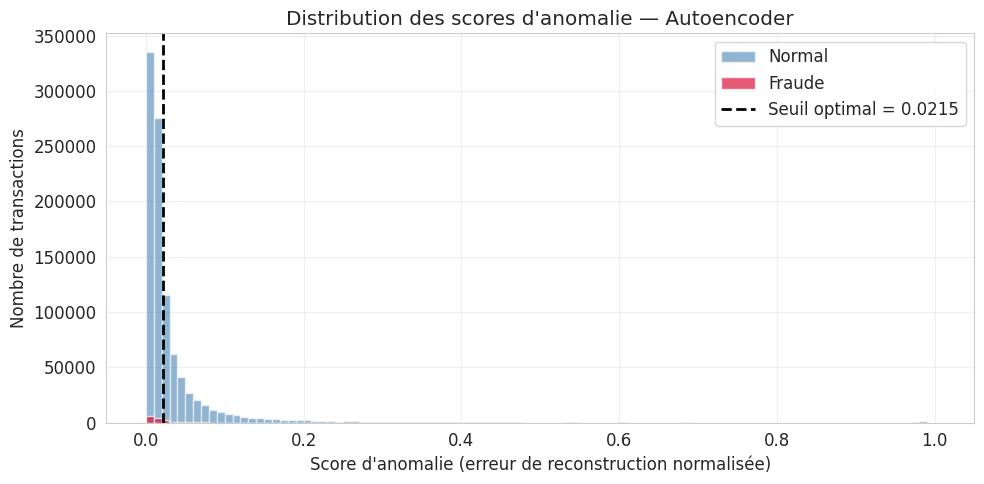

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ae_scores_norm[y.flatten() == 0], bins=100, alpha=0.6,
        label='Normal', color='steelblue')
ax.hist(ae_scores_norm[y.flatten() == 1], bins=100, alpha=0.7,
        label='Fraude', color='crimson')
ax.axvline(best_threshold, color='black', linestyle='--', lw=2,
           label=f'Seuil optimal = {best_threshold:.4f}')
ax.set_xlabel("Score d'anomalie (erreur de reconstruction normalisée)")
ax.set_ylabel('Nombre de transactions')
ax.set_title("Distribution des scores d'anomalie — Autoencoder")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_PATH + 'ae_score_distribution.png', dpi=150)
plt.show()

## 💾 13. Sauvegarde

In [18]:
autoencoder.save(MODELS_PATH + 'autoencoder.keras')
encoder.save(MODELS_PATH + 'encoder.keras')
joblib.dump(best_threshold, MODELS_PATH + 'autoencoder_threshold.pkl')
np.save(BASE_PATH + 'ae_scores.npy',    ae_scores_norm)
np.save(BASE_PATH + 'ae_threshold.npy', np.array([best_threshold]))

# Test de rechargement
loaded_ae        = keras.models.load_model(MODELS_PATH + 'autoencoder.keras')
loaded_threshold = joblib.load(MODELS_PATH + 'autoencoder_threshold.pkl')
test_recon       = loaded_ae.predict(X_all[:5], verbose=0)
test_scores      = np.mean(np.square(X_all[:5] - test_recon), axis=1)
test_scores_norm = (test_scores - ae_scores.min()) / \
                   (ae_scores.max() - ae_scores.min())
test_pred        = (test_scores_norm >= loaded_threshold).astype(int)
print(f'🔁 Test rechargement OK — prédictions : {test_pred}')

print('\n📁 Fichiers produits :')
print(f'   models/autoencoder.keras')
print(f'   models/encoder.keras')
print(f'   models/autoencoder_threshold.pkl')
print(f'   data/ae_scores.npy')
print(f'   data/ae_threshold.npy')
print(f'   models/ae_learning_curve.png')
print(f'   models/ae_confusion_matrix_init.png')
print(f'   models/ae_confusion_matrix_optimal.png')
print(f'   models/ae_roc_pr_curves.png')
print(f'   models/ae_score_distribution.png')

🔁 Test rechargement OK — prédictions : [0 0 0 0 1]

📁 Fichiers produits :
   models/autoencoder.keras
   models/encoder.keras
   models/autoencoder_threshold.pkl
   data/ae_scores.npy
   data/ae_threshold.npy
   models/ae_learning_curve.png
   models/ae_confusion_matrix_init.png
   models/ae_confusion_matrix_optimal.png
   models/ae_roc_pr_curves.png
   models/ae_score_distribution.png


## 📝 14. Résumé final

In [19]:
print('=' * 55)
print('         RÉSUMÉ FINAL — AUTOENCODER')
print('=' * 55)
print(f'  Dataset          : {len(y):,} transactions')
print(f'  Taux de fraude   : {y.mean()*100:.2f}%')
print(f'  Entraînement     : {X_normal.shape[0]:,} transactions normales')
print(f'  Architecture     : {input_dim} → 64 → 32 → {latent_dim} → 32 → 64 → {input_dim}')
print(f'  Époques          : {len(history.history["loss"])}')
print(f'  Seuil optimal    : {best_threshold:.4f}')
print('-' * 55)
print(f'  ROC-AUC          : {roc_final:.4f}')
print(f'  PR-AUC           : {pr_final:.4f}')
print(f'  F1-Score         : {f1_final:.4f}')
print('=' * 55)
print('\n→ Ces métriques sont à reporter dans le tableau comparatif')
print('  AE vs IF du notebook 05_comparaison.ipynb')

         RÉSUMÉ FINAL — AUTOENCODER
  Dataset          : 1,000,000 transactions
  Taux de fraude   : 1.71%
  Entraînement     : 982,857 transactions normales
  Architecture     : 43 → 64 → 32 → 8 → 32 → 64 → 43
  Époques          : 50
  Seuil optimal    : 0.0215
-------------------------------------------------------
  ROC-AUC          : 0.4921
  PR-AUC           : 0.0169
  F1-Score         : 0.0325

→ Ces métriques sont à reporter dans le tableau comparatif
  AE vs IF du notebook 05_comparaison.ipynb
